# Vertical edge focusing of a tilted dipole end -- measured by particle tracking

Companion of `hodograph_bending_sy` (which shapes the **s-y** longitudinal end so the pole
face stays at $B_0$).  This unit answers the **orthogonal** question: what a *horizontal*
edge tilt $\beta$ (a rotation of the pole face about the vertical axis, in the $x$-$s$ bend
plane) does to the **vertical** optics.

**Hard-edge optics.** A dipole edge tilted by $\beta$ acts as a thin vertical lens whose
strength is
$$ \left|\frac{1}{f_z}\right| = \frac{\tan\beta}{\rho}, \qquad \rho = \frac{p}{qB_0}\ \text{(bend radius)}. $$
The **magnitude** $\tan\beta/\rho$ is the convention-independent, delicate quantity; the
**sign** is orientation-dependent (a rectangular magnet's edges *defocus* vertically; the
curl-free entrance-edge orientation modeled here *focuses*, giving $1/f_z=+\tan\beta/\rho$).

**Why tracking, not a field-EFB slope.** The vertical edge focusing is a *second-order,
off-mid-plane* property of the fringe.  The effective-field-boundary (EFB) slope of the
mid-plane $|B|$ **cannot** recover it -- it is wrong-sign / blows up on a compact dipole
(lab finding `edge_focusing_efb_slope_negative`).  The correct measurement is the
linearized vertical **Hill integral** along the reference orbit,
$$ \frac{1}{f_z} = \frac{q}{p}\int\!\Big(u_y\,\frac{\partial B_x}{\partial z} - u_x\,\frac{\partial B_y}{\partial z}\Big)\Big|_{z=0}\,ds, $$
with $u$ the mid-plane orbit tangent.  Below we validate that measurement on a field whose
answer is known in closed form.

In [1]:
import os, sys, json, platform, datetime
import numpy as np
sys.path.insert(0, os.getcwd())
import edge_focusing_tracking as ef
from IPython.display import Image, display

print(f"flat-top field B0 = {ef.B0} T, reference bend radius rho = {ef.RHO_REF} m")
print(f"reference fringe width w = {ef.W} m; beta sweep = {ef.BETAS_DEG} deg")

flat-top field B0 = 1.0 T, reference bend radius rho = 1.0 m
reference fringe width w = 0.02 m; beta sweep = [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0] deg


## 1. The tracker recovers the hard-edge law

Build a genuinely **Maxwellian** tilted hard-edge fringe (curl-free *and* div-free -- the
only vacuum linear-in-$z$ continuation of the mid-plane profile is $B_s=+B_0\,z\,g'(s)$; a
div-free-but-not-curl-free choice has a spurious current sheet at the edge and *flips the
sign*).  Track the reference orbit through it and evaluate the Hill integral.

In [2]:
sw = ef.sweep_beta()   # rho=1 m, w=0.02 m
print(f"{'beta[deg]':>9}{'tracked 1/f_z':>16}{'hard-edge tan/rho':>20}{'rel.err':>10}")
for r in sw:
    rel = (abs(r['inv_fz'] - r['hard_edge']) / abs(r['hard_edge'])
           if abs(r['hard_edge']) > 1e-9 else float('nan'))
    print(f"{r['beta_deg']:>9.1f}{r['inv_fz']:>+16.5f}{r['hard_edge']:>+20.5f}"
          f"{rel*100:>9.2f}%")

beta[deg]   tracked 1/f_z   hard-edge tan/rho   rel.err
      0.0        -0.01000            +0.00000      nan%
      5.0        +0.07740            +0.08749    11.53%
     10.0        +0.16591            +0.17633     5.91%
     15.0        +0.25694            +0.26795     4.11%
     20.0        +0.35205            +0.36397     3.28%
     25.0        +0.45306            +0.46631     2.84%
     30.0        +0.56223            +0.57735     2.62%


## 2. Convergence to the hard-edge limit, and the $1/\rho$ scaling

Two rigorous checks that this *is* the hard-edge edge focusing:

* **$w\to0$ convergence.** The least-squares slope $c(w)$ of the tracked $1/f_z$ against the
  law rises $0.84\to0.99$ as the fringe narrows -- a finite fringe simply spreads the
  delta-function edge.
* **$\beta=0$ baseline is a finite-fringe residual.** With a normal (untilted) edge the
  hard-edge focusing is exactly $0$; the tracker returns $-\tfrac12\,w/\rho$, an
  $O(w/\rho)$ residual that vanishes as $w\to0$.
* **$1/\rho$ scaling (thin lens).** $\;\rho\cdot(1/f_z)$ collapses onto $\tan\beta$ across
  $\rho$.

In [3]:
wc = ef.w_convergence()   # w: 0.08 -> 0.005 m
rc = ef.rho_collapse()    # rho: 0.7, 1.0, 1.6 m
print("w-convergence (slope of tracked 1/f_z vs the hard-edge law):")
for d in wc:
    print(f"  w={d['w']:.3f} m -> slope {d['slope_vs_law']:.4f}")
print("\nbeta=0 baseline vs w (= -0.5 w/rho, a finite-fringe residual -> 0):")
for w in (0.04, 0.02, 0.01):
    b = ef.edge_focus_integral(ef.edge_field(0.0, w=w), 1.0)['inv_fz']
    print(f"  w={w:.3f} m -> 1/f_z(beta=0) = {b:+.5f}  (-0.5 w/rho = {-0.5*w:+.5f})")
s = ef.summarize(sw, wc)
print(f"\nfinest-w slope {s['finest_w_slope']:.4f} (hard-edge limit 1.000)")

w-convergence (slope of tracked 1/f_z vs the hard-edge law):
  w=0.080 m -> slope 0.8385
  w=0.040 m -> slope 0.9182
  w=0.020 m -> slope 0.9588
  w=0.010 m -> slope 0.9793
  w=0.005 m -> slope 0.9896

beta=0 baseline vs w (= -0.5 w/rho, a finite-fringe residual -> 0):


  w=0.040 m -> 1/f_z(beta=0) = -0.02002  (-0.5 w/rho = -0.02000)


  w=0.020 m -> 1/f_z(beta=0) = -0.01000  (-0.5 w/rho = -0.01000)


  w=0.010 m -> 1/f_z(beta=0) = -0.00500  (-0.5 w/rho = -0.00500)

finest-w slope 0.9896 (hard-edge limit 1.000)


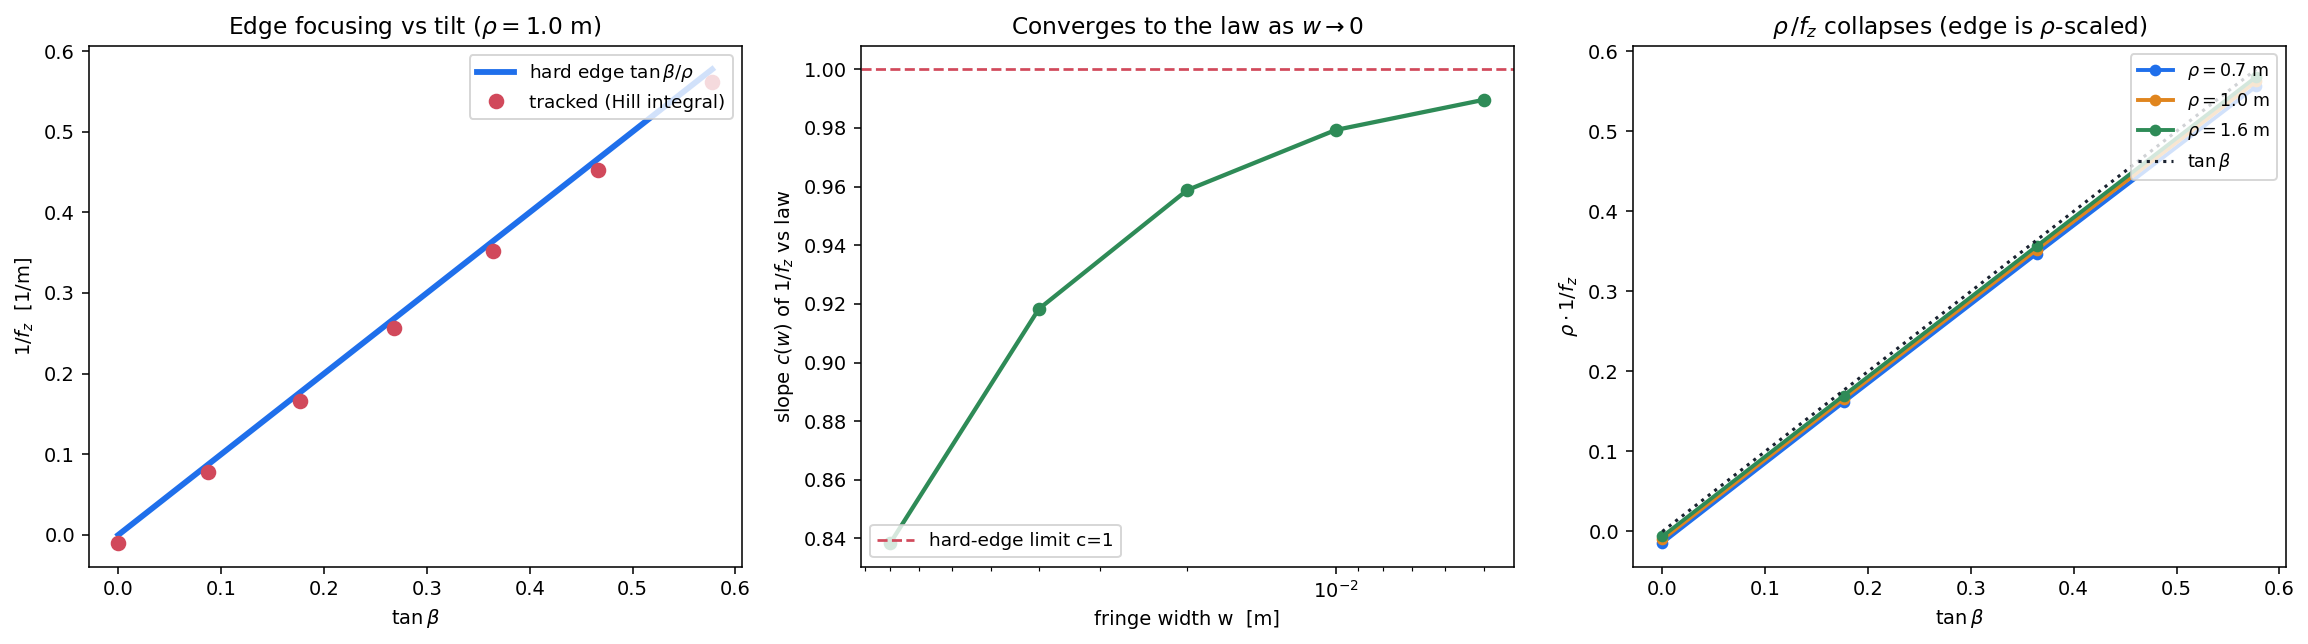

In [4]:
display(Image(filename=ef.figure_edge_focus(sw, wc, rc, "edge_focusing_tracking.png")))

## 3. Honest scope -- the analytic method is verified; the 3D-FEM extraction is not (yet)

**What is verified here (clean):** on a field whose answer is known in closed form, the
particle-tracking Hill integral reproduces the hard-edge vertical edge focusing
$|1/f_z|=\tan\beta/\rho$ (slope $\to1$ as $w\to0$, $\rho$-collapse, $O(w/\rho)$ baseline).
This is the **correct method** -- the field-EFB slope of the mid-plane $|B|$ cannot measure
edge focusing at all.

**What is *not* clean (honest partial):** applying the *same* tracker to a **3D FEM** tilted-
edge dipole field (reduced-$\Omega$, `accel_pole_ends_fem`) recovers the right *scaling*
$\Delta(1/f_z)\propto\tan\beta/\rho$ but not a trustworthy magnitude.  A *wide-pole* attempt
(so $\partial B_z/\partial x\approx0$ on-axis -- verified the orbit stays at $x\approx3$ mm)
with the tilted$-$normal **difference** (to cancel the body term) *still* fails: the
$\beta=0$ baseline ($-0.17$ at $\rho=2$ m) does **not** cancel and the difference is
non-monotone / wrong-sign ($\beta=15^\circ\to-0.03$, $\beta=30^\circ\to+0.017\approx6\%$ of
$\tan\beta/\rho$).  The **root reason** is deeper than orbit drift: a real finite-**gap**
dipole fringe is *thick and fully 3-D* (fringe width $\sim$ the gap), so the hard-edge thin-
lens $\tan\beta/\rho$ is **not the recoverable target** of the naive Hill integral -- the
tilted and normal fringes differ in *more* than the edge angle.  Recovering $\tan\beta/\rho$
from a thick FEM fringe needs the **SCOFF / Enge fringe-field-integral** formalism plus a
proper **closed orbit** and a finer mesh -- a substantial further build.  That difficulty is
the lab finding `edge_focusing_efb_slope_negative` in stronger form (field-based edge
measures are fragile), so the tracked-on-analytic result above is the durable artifact.

In [5]:
def _ver(m):
    try:
        return __import__(m).__version__
    except Exception:
        return None

payload = {
    "generated_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "radia_version": _ver("radia"), "ngsolve_version": _ver("ngsolve"),
    "python_version": platform.python_version(), "platform": platform.platform(),
    "B0": ef.B0, "rho_ref": ef.RHO_REF, "w_ref": ef.W, "betas_deg": ef.BETAS_DEG,
    "sweep_beta": sw, "w_convergence": wc, "rho_collapse": rc,
    "summary": ef.summarize(sw, wc),
}
with open("edge_focusing_tracking.json", "w") as fh:
    json.dump(payload, fh, indent=2)
print("saved edge_focusing_tracking.json  (finest-w slope %.4f; max rel err vs law %.2f%%)"
      % (payload["summary"]["finest_w_slope"], payload["summary"]["max_rel_err_vs_law"]*100))

saved edge_focusing_tracking.json  (finest-w slope 0.9896; max rel err vs law 11.53%)
